### **문제 A: 영상 변형 및 관심 영역 처리 (25분)**

**문제 설명:**
주어진 `complex_scene.jpg` 이미지 파일을 읽어와 아래 요구사항을 충족하는 파이썬 코드를 작성하세요.

1. **이미지 로드 및 크기 조정:**
    - `complex_scene.jpg` 파일을 로드하고, 가로 640픽셀, 세로 480픽셀로 크기를 조정한 후 `resized_image.jpg`로 저장하세요.
    - **힌트:** `cv2.resize()` 함수를 활용하세요.
2. **관심 영역(ROI) 추출 및 블러 처리:**
    - 크기 조정된 이미지에서 특정 좌표(예: 좌상단 (100, 100), 우하단 (400, 300))를 관심 영역(ROI)으로 설정하세요.
    - 설정된 ROI 영역에 `cv2.GaussianBlur()` 함수를 사용하여 가우시안 블러(커널 크기 (25, 25), 시그마 값 0)를 적용하세요.
    - 블러 처리된 ROI를 원본 이미지에 다시 적용하여, ROI만 블러 처리된 새로운 이미지를 생성하세요.
3. **결과 이미지 저장:**
    - ROI가 블러 처리된 최종 이미지를 `blurred_roi_scene.png`라는 파일명으로 저장하세요.

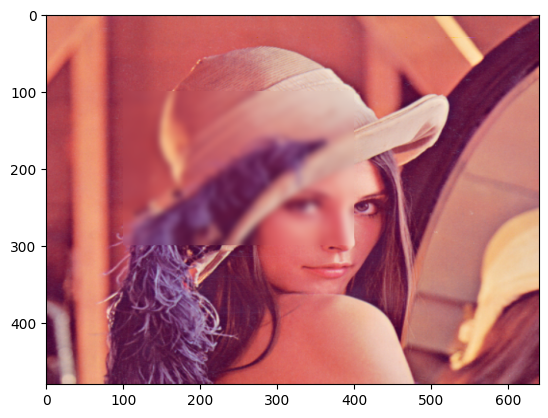

True

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_array = cv2.imread('complex_scene.jpg')
img = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (640,480))


roi = img[100:300, 100:400]
blurred_roi = cv2.GaussianBlur(roi, (25, 25), 0)

img[100:300, 100:400] = blurred_roi

plt.imshow(img)
plt.show()

cv2.imwrite('blurred_roi_scene.png', img)

### **문제 B: YOLO 객체 탐지 및 후처리 (35분)**

**문제 설명:**
주어진 `crowded_street.jpg` 이미지 파일에 대해 사전 학습된 YOLOv8 모델을 사용하여 객체를 탐지하고, 탐지 결과에 대한 후처리를 수행하는 코드를 작성하세요.

1. **모델 로드 및 객체 탐지:**
    - `yolov8m.pt` 모델을 로드하세요. (`yolov8n.pt`보다 큰 모델을 사용합니다.)
    - 로드한 모델을 사용하여 `crowded_street.jpg` 파일 내의 모든 객체를 탐지하고 결과를 `results` 변수에 저장하세요.
    - **힌트:** `ultralytics` 라이브러리의 `YOLO` 클래스와 `predict` 메서드를 사용하세요.
2. **특정 객체 카운트 및 필터링:**
    - 탐지된 객체 중 **'person'**과 **'bicycle'** 클래스에 해당하는 객체의 수를 각각 계산하여 출력하세요.
    - 신뢰도(confidence score)가 **0.7 이상**인 'person' 객체만 필터링하여, 이들의 바운딩 박스 좌표와 신뢰도, 클래스 이름을 출력하세요.
3. **결과 시각화 및 저장:**
    - 원본 이미지에 신뢰도 0.7 이상인 **'person'** 객체의 바운딩 박스와 클래스 이름, 신뢰도를 그려서 시각화하세요. 다른 객체는 시각화하지 않습니다.
    - 시각화된 이미지를 `filtered_person_detection.jpg`라는 파일명으로 저장하세요.
    - **힌트:** `results[0].boxes` 객체에서 필터링 조건을 적용하여 수동으로 그리는 방식을 고려하거나, `results.plot()` 메서드를 사용하되 필요에 따라 후처리 로직을 추가해야 할 수 있습니다.


image 1/1 c:\Users\Sanghwa\study-and-commit\test2\crowded_street.jpg: 416x640 9 persons, 27 cars, 8 motorcycles, 1 bus, 3 trucks, 231.4ms
Speed: 1.8ms preprocess, 231.4ms inference, 4.5ms postprocess per image at shape (1, 3, 416, 640)


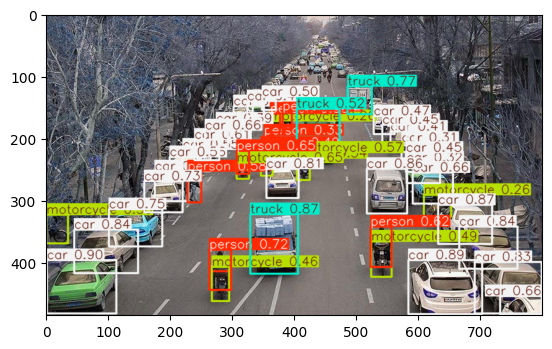

In [21]:
#문제 1
from ultralytics import YOLO

model = YOLO('yolov8m.pt')

results = model('crowded_street.jpg')
original_img = cv2.imread('crowded_street.jpg')
plotted_img = results[0].plot()

plt.imshow(plotted_img)
plt.show()

In [ ]:
# 문제 2-1
boxes = results[0].boxes

cnt_person = 0
cnt_bicycle = 0
for box in boxes:
    # 클래스 ID와 신뢰도 점수 가져오기
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # 바운딩 박스 좌표 (x1, y1, x2, y2) 가져오기
    xyxy = box.xyxy[0].tolist()
    
    # 클래스 이름 가져오기
    class_name = model.names[class_id]
    
    # 추출된 정보 출력
    if class_name == 'person':
        cnt_person +=1
    if class_name == 'bicycle':
        cnt_bicycle += 1

print(cnt_person)
print(cnt_bicycle)

9
0


In [ ]:
# 문제 2-2
for box in boxes:
    # 클래스 ID와 신뢰도 점수 가져오기
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # 바운딩 박스 좌표 (x1, y1, x2, y2) 가져오기
    xyxy = box.xyxy[0].tolist()
    
    # 클래스 이름 가져오기
    class_name = model.names[class_id]
    
    # 추출된 정보 출력
    if class_name == 'person' and confidence > 0.7:
        print(f"클래스: {class_name}")
        print(f"좌표(xyxy): [{xyxy[0]:.2f}, {xyxy[1]:.2f}, {xyxy[2]:.2f}, {xyxy[3]:.2f}]")
        print(f"신뢰도: {confidence:.2f}")
        print("-" * 20)

클래스: person
좌표(xyxy): [263.22, 379.06, 298.31, 444.53]
신뢰도: 0.72
--------------------


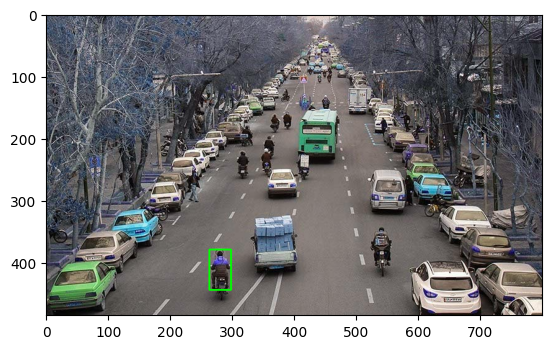

True

In [ ]:
# 문제 3
color = (0, 255, 0)      # 초록색
thickness = 2            # 바운딩 박스 선 두께

for box in boxes:
    # 클래스 ID와 신뢰도 점수 가져오기
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # 바운딩 박스 좌표 (x1, y1, x2, y2) 가져오기
    xyxy = box.xyxy[0].tolist()
    
    # 클래스 이름 가져오기
    class_name = model.names[class_id]
    
    # 추출된 정보 출력
    if class_name == 'person' and confidence > 0.7:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cv2.rectangle(original_img, (x1, y1), (x2, y2), color, thickness)
        
plt.imshow(original_img)
plt.show()

cv2.imwrite('filtered_person_detection.jpg', original_img)

### **문제 C: YOLO 전이 학습 및 모델 재가중치 저장 (30분)**

**문제 설명:**
특정 환경에 맞게 새로운 객체(예: 'drone')를 인식하기 위해 YOLOv8 모델을 전이 학습하고, 학습 과정 중 최적의 가중치를 저장하는 코드를 작성하세요.

1. **데이터셋 및 설정 파일 확인:**
    - `./drone_dataset/` 디렉터리에 'drone' 객체가 포함된 이미지와 레이블 파일, 그리고 `drone_data.yaml` 설정 파일이 준비되어 있다고 가정하세요.
    - `drone_data.yaml` 파일에는 데이터셋 경로, 클래스 이름(예: `names: ['drone']`), 그리고 학습/검증 데이터 경로가 정의되어 있습니다.
2. **전이 학습 수행:**
    - `yolov8n.yaml` 모델 구성을 기반으로 `yolov8n.pt` 사전 학습 가중치를 사용하여 모델을 초기화하세요.
    - `drone_data.yaml`에 정의된 데이터셋으로 모델을 훈련하세요.
        - **epochs는 20으로 설정하세요.** (실제 학습 시간 단축을 위함)
        - **이미지 크기는 640x640으로 설정하세요.**
        - **배치 크기는 8로 설정하세요.**
    - **힌트:** `model.train()` 메서드의 `data`, `epochs`, `imgsz`, `batch` 인자를 적절히 활용하세요.
3. **학습된 모델 가중치 저장:**
    - 학습 완료 후, **가장 성능이 좋았던(best)** 모델의 가중치를 `best_drone_model.pt`라는 파일명으로 저장하세요.
    - **힌트:** Ultralytics YOLO는 학습 완료 후 `runs/detect/trainX/weights/best.pt` 경로에 최적의 모델 가중치를 자동으로 저장합니다. 이 파일을 지정된 이름으로 복사하는 코드를 추가하거나, 학습 시 `name` 인자를 사용하여 저장 경로를 지정할 수 있습니다.

In [24]:
import shutil
import os

# 2. 전이 학습 수행
# `drone_data.yaml` 파일에 정의된 데이터셋으로 학습합니다.
print("YOLOv8 모델 전이 학습 시작...")
results = model.train(
    data='Drone.v3i.yolov8/data.yaml',
    epochs=20,
    imgsz=640,
    batch=8,
    name='train_drone_detection'  # 학습 결과가 저장될 디렉터리 이름
)
print("YOLOv8 모델 전이 학습 완료!")

# 3. 최적의 가중치 저장
# 학습 완료 후, 최적 가중치 파일 `best.pt`를 복사하여 `best_drone_model.pt`로 저장합니다.
# Ultralytics는 `runs/detect/` 하위에 학습 결과를 저장합니다.
source_path = os.path.join(results.save_dir, 'weights', 'best.pt')
destination_path = 'best_drone_model.pt'

if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"최적 모델 가중치가 '{destination_path}'에 성공적으로 저장되었습니다.")
else:
    print("학습된 가중치 파일을 찾을 수 없습니다. 경로를 확인하세요.")

YOLOv8 모델 전이 학습 시작...
New https://pypi.org/project/ultralytics/8.3.201 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.199  Python-3.13.3 torch-2.7.0+cpu CPU (12th Gen Intel Core i5-12450H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Drone.v3i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_drone_det

KeyboardInterrupt: 